# The Geometry of Data - A Visual Guide to Linear Algebra in NumPy

*Author: Eda Aydın*

*Description: This notebook accompanies the blog post "The Geometry of Data". It visualizes vectors, matrices, dot products, transformations, and PCA step-by-step to build intuition.*

*Date: 06/18/2026*

## 0. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set a nice style for plots
plt.style.use('seaborn-v0_8-whitegrid')

# Helper Function: Plotting Vectors easily
def plot_vectors(vectors, colors, title, xlim=(-5, 5), ylim=(-5, 5)):
    """
    Plots multiple 2D vectors starting from the origin.
    Args:
        vectors: List of np.arrays or lists [x, y]
        colors: List of color strings
        title: Title of the plot
    """
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    
    # Plot the arrows
    for i, vec in enumerate(vectors):
        ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=colors[i], label=f'Vector {i+1}: {vec}')

    # Setup axis
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal') # CRUCIAL for geometry
    ax.axhline(0, color='black',linewidth=1)
    ax.axvline(0, color='black',linewidth=1)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print("Setup complete. Helpers defined.")

Setup complete. Helpers defined.


## 1. Vectors: Points in Space

In AI, a vector is a data point.

Geometrically, it's an arrow from origin to coordinates.

Vector 1 (Age, BP): [3 1]
Vector 2: [-2  4]


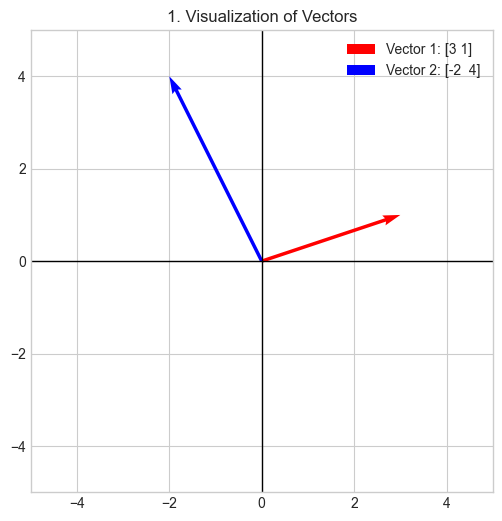

In [2]:
# Define two 2D vectors
v1 = np.array([3, 1])
v2 = np.array([-2, 4])

print(f"Vector 1 (Age, BP): {v1}")
print(f"Vector 2: {v2}")

# Visualize them
plot_vectors([v1, v2], ['r', 'b'], "1. Visualization of Vectors")

## 2. Fundamental Movements (Verbs)

### 2a. Vector Addition (Translation)

Sum (v1 + v2): [1 5]


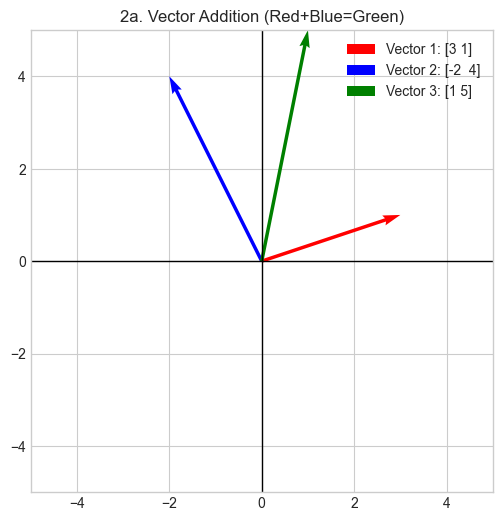

In [4]:
# Geometrically: Placing arrows tail-to-head.
v_sum = v1 + v2
print(f"Sum (v1 + v2): {v_sum}")

plot_vectors([v1, v2, v_sum], ['r', 'b', 'g'], "2a. Vector Addition (Red+Blue=Green)")

### 2b. Dot Product (Similarity & Projection)

In [5]:
# Dot product tells us how much vectors align.
# v1 . v2 = |v1||v2| cos(theta)

v1 = np.array([3, 0])
v2_aligned = np.array([2, 0])  # Perfect alignment
v3_perp = np.array([0, 4])     # Perpendicular (90 deg)
v4_opp = np.array([-1, 0])     # Opposite direction

dot_aligned = np.dot(v1, v2_aligned)
dot_perp = np.dot(v1, v3_perp)
dot_opp = np.dot(v1, v4_opp)

print(f"v1: {v1}")
print(f"Dot product (Aligned): {dot_aligned} (High positive)")
print(f"Dot product (Perpendicular): {dot_perp} (Zero - No similarity)")
print(f"Dot product (Opposite): {dot_opp} (Negative similarity)")

v1: [3 0]
Dot product (Aligned): 6 (High positive)
Dot product (Perpendicular): 0 (Zero - No similarity)
Dot product (Opposite): -3 (Negative similarity)


## 3. Matrices As Spatial Transformations

The Core AI Intuition: Multiplying a vector by a matrix (A@v) does NOT move a point; it bended/transforms the *entire space*.

In [10]:
# Let's define a simple shape (a square) made of vectors
square = np.array([
    [0, 0], [1, 0], [1, 1], [0, 1], [0, 0]
]).T # Transposed to make columns vectors

v_original = np.array([1, 1]) # A vector pointing to the top-right corner

def plot_transformation(matrix, title):
    # Transform the square and the original vector
    transformed_square = matrix @ square
    v_transformed = matrix @ v_original
    
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    
    # Plot Original Space (Gray grid approximation)
    plt.plot(square[0, :], square[1, :], color='gray', linestyle='--', label='Original Space')
    ax.quiver(0, 0, v_original[0], v_original[1], angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.5)

    # Plot Transformed Space (Blue)
    # Replaced invalid fontweight='bold' with linewidth=2
    plt.plot(transformed_square[0, :], transformed_square[1, :], color='blue', linewidth=2, label='Transformed Space')
    ax.quiver(0, 0, v_transformed[0], v_transformed[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Transformed Vector')

    # Setup axis
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='black',linewidth=1)
    ax.axvline(0, color='black',linewidth=1)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print("Transformation helpers defined.")

Transformation helpers defined.


### 3a. Scaling Matrix (Streching/Squeezing)

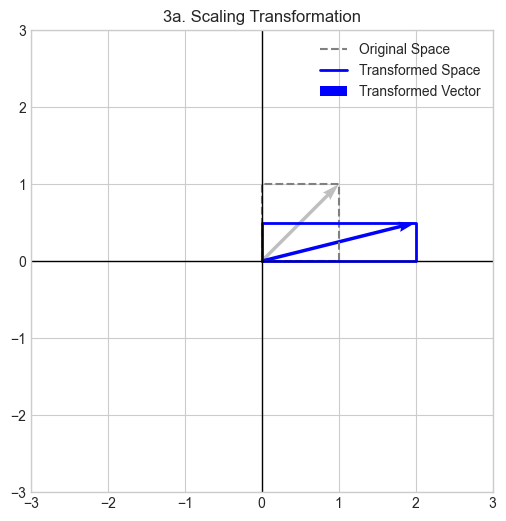

In [11]:
# S = [[sx, 0], [0, sy]]
S = np.array([
    [2, 0],   # Stretch X by 2
    [0, 0.5]  # Squeeze Y by 0.5
])
plot_transformation(S, "3a. Scaling Transformation")

### 3b. Rotation Matrix (Rotating Space)

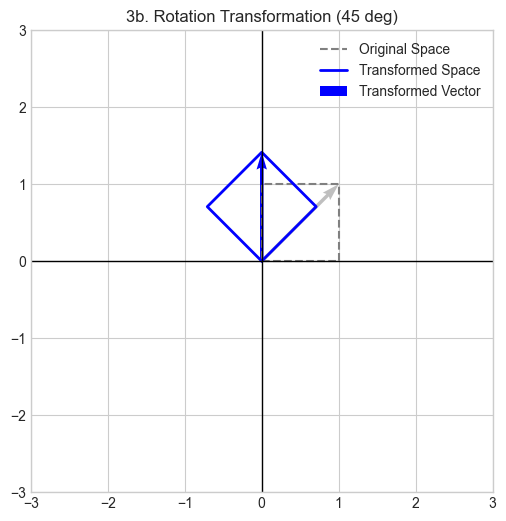

In [12]:
# R = [[cos(t), -sin(t)], [sin(t), cos(t)]]
theta = math.radians(45) # Rotate by 45 degrees
R = np.array([
    [math.cos(theta), -math.sin(theta)],
    [math.sin(theta), math.cos(theta)]
])
plot_transformation(R, "3b. Rotation Transformation (45 deg)")

### 3c. Shear Matrix (Slanting Space)

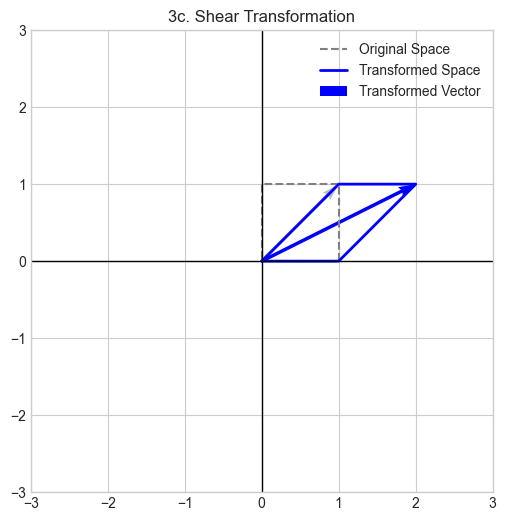

In [13]:
# Sh = [[1, k], [0, 1]]
Sh = np.array([
    [1, 1], # Slant X based on Y
    [0, 1]
])
plot_transformation(Sh, "3c. Shear Transformation")

## 4. Eigenvectors & Eigenvalues: The Invariant Directions

In a transformation, some directions remain unchanged.

Av = lambda * v

In [14]:
A = np.array([
    [3, 1],
    [0, 2]
])

# Calculate Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Matrix A (Transformation):\n{A}")
print(f"Eigenvalues: {eigenvalues}")
# Eigenvectors are columns
print(f"Eigenvector 1 (dir of eval={eigenvalues[0]}):\n{eigenvectors[:, 0]}")
print(f"Eigenvector 2 (dir of eval={eigenvalues[1]}):\n{eigenvectors[:, 1]}")

Matrix A (Transformation):
[[3 1]
 [0 2]]
Eigenvalues: [3. 2.]
Eigenvector 1 (dir of eval=3.0):
[1. 0.]
Eigenvector 2 (dir of eval=2.0):
[-0.70710678  0.70710678]


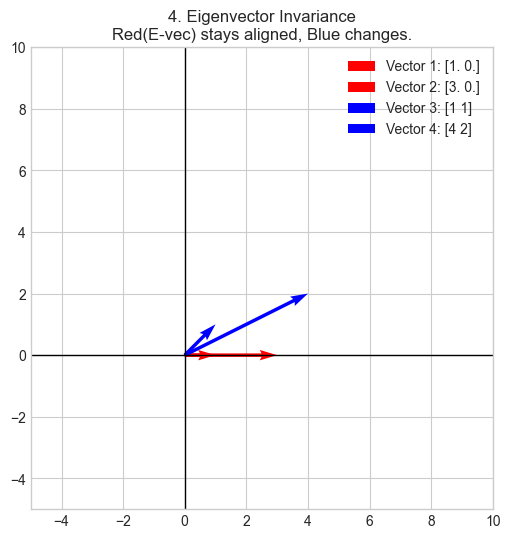

In [15]:
# Visualizing Eigenvectors under Transformation A
v1 = eigenvectors[:, 0] # First Eigenvector direction
v2 = np.array([1, 1]) # A random non-eigenvector direction

A_v1 = A @ v1 # Should be same direction, just scaled by eigenvalues[0]
A_v2 = A @ v2 # Will change direction

# Normalized for plotting clarity
plot_vectors([v1, A_v1, v2, A_v2], 
             ['r', 'r', 'b', 'b'], 
             f"4. Eigenvector Invariance\nRed(E-vec) stays aligned, Blue changes.",
             xlim=(-5, 10), ylim=(-5, 10))

## 5. Real World Application: PCA (Principal Component Analysis)

PCA finds eigenvectors of the covariance matrix to identify the axes of maximum variance in the data, allowing for dimensionality reduction while preserving essential information.

### 5a. Generate synthetic 2D data with a clear trend (correlation)

In [16]:
np.random.seed(42)
N = 100
x = np.random.normal(0, 1, N)
y = 2 * x + np.random.normal(0, 0.5, N) # Y depends on X, with some noise
data = np.vstack([x, y]).T

### 5b. Center the data (Subtract Mean) - Essential for PCA

In [17]:
data_centered = data - np.mean(data, axis=0)

### 5c. Calculate Covariance Matrix

In [18]:
cov_matrix = np.cov(data_centered, rowvar=False)
print(f"Covariance Matrix:\n{cov_matrix}")

Covariance Matrix:
[[0.82476989 1.59046269]
 [1.59046269 3.29014231]]


### 5d. Eigendecomposition of Covariance Matrix

In [20]:
evals, evecs = np.linalg.eig(cov_matrix)

# Sort them (PCA keeps top eigenvalues)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

print(f"Sorted Eigenvalues (Variance along axes):\n{evals}")
print(f"Principal Components (Eigenvectors):\n{evecs}")

Sorted Eigenvalues (Variance along axes):
[4.0696904  0.04522181]
Principal Components (Eigenvectors):
[[-0.44011603 -0.89794091]
 [-0.89794091  0.44011603]]


### 5e. Visualization: Plotting Data and Principal Components

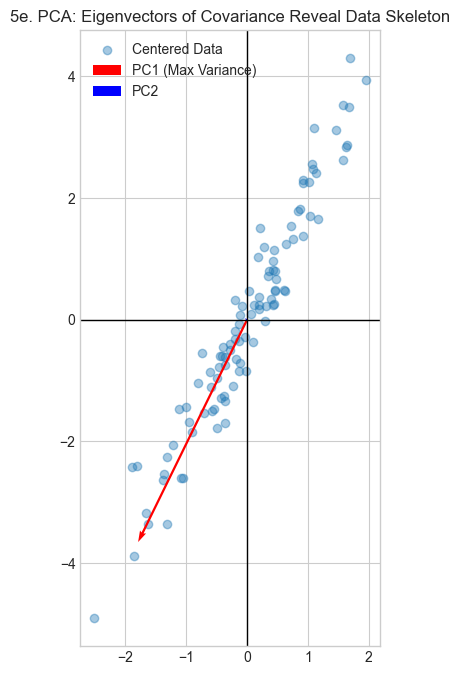

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.4, label='Centered Data')

# Plot Principal Components scaled by their eigenvalues (variance)
origin = [0, 0]
plt.quiver(*origin, *evecs[:, 0]*evals[0], color='r', scale=1, scale_units='xy', angles='xy', label='PC1 (Max Variance)')
plt.quiver(*origin, *evecs[:, 1]*evals[1], color='b', scale=1, scale_units='xy', angles='xy', label='PC2')

plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.gca().set_aspect('equal')
plt.title("5e. PCA: Eigenvectors of Covariance Reveal Data Skeleton")
plt.legend()
plt.grid(True)
plt.show()

### 5f. Dimensionality Reduction (Project to 1D)

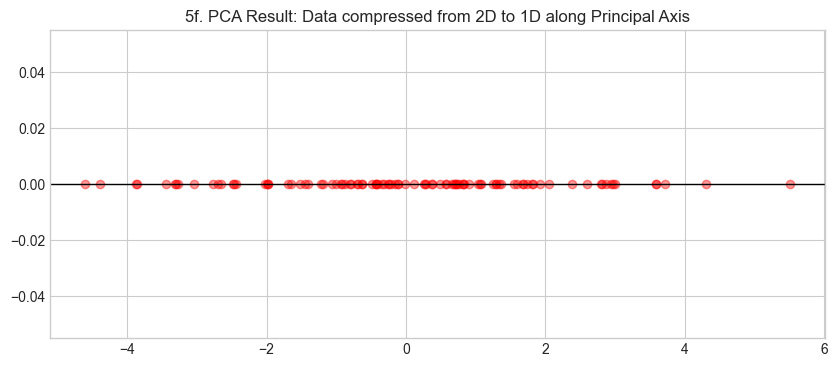

In [22]:
# Keep only the top component (PC1)
pc1_direction = evecs[:, 0]

# Project centered data onto PC1 axis
data_reduced_1d = data_centered @ pc1_direction

# Visualize the 1D projection vs Original 2D spread
plt.figure(figsize=(10, 4))
plt.scatter(data_reduced_1d, np.zeros_like(data_reduced_1d), alpha=0.4, color='r')
plt.axhline(0, color='black',linewidth=1)
plt.title("5f. PCA Result: Data compressed from 2D to 1D along Principal Axis")
plt.grid(True)
plt.show()